# 04_01. Distinct isoforms per gene — ranked scatter

In [1]:
print("Hello World")

Hello World


In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, gc
warnings.filterwarnings('ignore')
gc.enable()

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"
CSVS_DIR = "./../csvs"
FIG_DIR  = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.labelspacing": 0.1, "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2, "legend.title_fontsize": 6,
    "figure.titlesize": 6, "axes.labelweight": "bold", "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD, "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300, 
})

if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

## 1. Load PacBio isoform `var` metadata

Read the per-isoform `var` table (gene symbol + detection count) from the pbids h5ad. If a
level without a precomputed `n_cells_by_counts` is chosen, detection is computed from the backed
matrix instead.

In [3]:
LEVEL       = "pbids"   # each var = distinct PacBio isoform model PB.X.Y
DETECT_MIN  = 1             # isoform counts as "expressed" if detected in >= this many cells
ROBUST_MIN  = 1            # robust threshold (matches 03_01 "expressed isoform")
N_LABEL     = 15           # number of top genes to annotate on the scatter

PACBIO_H5AD = f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_{LEVEL}_bc_anndata_preprocessed.h5ad"


def _decode(v):
    return np.array([x.decode() if isinstance(x, bytes) else x for x in v])


def read_var_col(f, name):
    """Read one var column from an open h5py file (handles categorical)."""
    o = f["var"][name]
    if isinstance(o, h5py.Group):
        return pd.Categorical.from_codes(o["codes"][:], categories=_decode(o["categories"][:]))
    v = o[:]
    return _decode(v) if v.dtype.kind in ("S", "O") else v


with h5py.File(PACBIO_H5AD, "r") as f:
    n_cells_total, n_iso = (int(x) for x in f["X"].attrs["shape"])
    iso_ids = _decode(f["var"][f["var"].attrs.get("_index", "_index")][:])
    gene_name = read_var_col(f, "gene_name")
    struct_cat = read_var_col(f, "pigeon_structural_category") if "pigeon_structural_category" in f["var"] else None
    # molecules per isoform, for the molecule-weighted novel fraction in 4b
    tot_counts = np.asarray(read_var_col(f, "total_counts")) if "total_counts" in f["var"] else None
    if "n_cells_by_counts" in f["var"]:
        n_cells_iso = np.asarray(read_var_col(f, "n_cells_by_counts"))
    else:
        n_cells_iso = None  # computed below from backed X

if n_cells_iso is None:
    # Fallback for levels without precomputed stats: stream detection from backed X
    print("n_cells_by_counts absent -> computing detection from backed matrix (slower)...")
    adata = sc.read_h5ad(PACBIO_H5AD, backed="r")
    n_cells_iso = np.asarray((adata.X > 0).sum(axis=0)).ravel()
    del adata; gc.collect()

var_df = pd.DataFrame({
    "gene_name": gene_name.astype(str) if hasattr(gene_name, "astype") else gene_name,
    "n_cells":   n_cells_iso,
})
if tot_counts is not None:
    var_df["n_molecules"] = tot_counts      # aligned before the gene-symbol filter
else:
    print("WARNING: var has no total_counts -> the molecule-weighted 4b panel will not run")
_pig = pd.read_csv(f"{CSVS_DIR}/all_samples_recollapsed_pigeon_classification.csv",
                   usecols=["isoform", "structural_category"], dtype=str)
_pigmap = dict(zip(_pig["isoform"], _pig["structural_category"]))
_hit = sum(1 for i in iso_ids if i in _pigmap)
print(f"pigeon atlas classification: {_hit:,} / {len(iso_ids):,} isoforms matched")
struct_cat = np.array([_pigmap.get(i, "nan") for i in iso_ids], dtype=object)
del _pig, _pigmap

if struct_cat is not None:
    var_df["structural_category"] = np.asarray(struct_cat).astype(str)
# drop isoforms with no gene symbol
var_df = var_df[~var_df["gene_name"].isin(["nan", "None", ""])].copy()

print(f"Level: {LEVEL} | {n_cells_total:,} cells x {n_iso:,} isoforms")
print(f"Isoforms with a gene symbol: {len(var_df):,} | unique genes: {var_df['gene_name'].nunique():,}")

pigeon atlas classification: 854,410 / 854,410 isoforms matched
Level: pbids | 203,311 cells x 854,410 isoforms
Isoforms with a gene symbol: 854,410 | unique genes: 37,805


## 2. Distinct isoforms per gene

Count distinct expressed isoforms per gene at each threshold, then rank genes descending.

In [4]:
def isoforms_per_gene(var_df, min_cells):
    """Number of distinct isoforms per gene detected in >= min_cells cells (ranked descending)."""
    sub = var_df[var_df["n_cells"] >= min_cells]
    counts = sub.groupby("gene_name", observed=True).size().sort_values(ascending=False)
    return counts

counts_detect = isoforms_per_gene(var_df, DETECT_MIN)
counts_robust = isoforms_per_gene(var_df, ROBUST_MIN)

for name, c, k in [("detected (>=%d cell)" % DETECT_MIN, counts_detect, DETECT_MIN),
                   ("robust (>=%d cells)" % ROBUST_MIN, counts_robust, ROBUST_MIN)]:
    print(f"[{name}] genes: {len(c):,} | total isoforms: {int(c.sum()):,} | "
          f"max/gene: {c.max():,} | median/gene: {c.median():.0f} | "
          f"genes with >1 isoform: {(c > 1).mean()*100:.1f}%")

print("\nTop 20 genes by distinct isoforms (robust >=%d cells):" % ROBUST_MIN)
print(counts_robust.head(20).to_string())

[detected (>=1 cell)] genes: 37,805 | total isoforms: 854,410 | max/gene: 874 | median/gene: 6 | genes with >1 isoform: 80.6%
[robust (>=1 cells)] genes: 37,805 | total isoforms: 854,410 | max/gene: 874 | median/gene: 6 | genes with >1 isoform: 80.6%

Top 20 genes by distinct isoforms (robust >=1 cells):
gene_name
CAST        874
DST         825
TTN         799
KTN1        790
SYNE2       785
EEF1A1      695
MACF1       684
SYNE1       671
SFTPC       653
UTRN        597
PCM1        574
LAMA2       568
MALAT1      560
ANKRD36C    491
VPS13C      473
GSN         452
AKAP13      444
CHD2        438
NBPF19      430
BAZ2B       423


## 3. Ranked scatter — distinct isoforms per gene

Genes ranked on the x-axis (most isoforms → fewest), y = number of distinct isoforms expressed.
Log–log axes; the top genes are labelled.

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


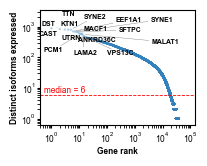

In [5]:
from adjustText import adjust_text
def ranked_scatter(counts, ax, title, n_label=N_LABEL, color="#3182bd", min_cells=ROBUST_MIN):
    c = counts.sort_values(ascending=False)
    ranks = np.arange(1, len(c) + 1)
    ax.scatter(ranks, c.values, s=3, alpha=0.35, edgecolors="none", color=color)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Gene rank")
    # y = number of distinct isoform models per gene, each isoform detected in >= min_cells cells
    ax.set_ylabel(f"Distinct isoforms expressed\n(each in >= {min_cells} cells)")
    ax.set_ylabel(f"Distinct isoforms expressed")
    ax.set_title(title, pad=PANEL_TITLE_PAD)
    # widen the axis limits (log-space multiplicative margin) so labels have room to move
    vmax = c.max(); vmin = c[c > 0].min()
    ax.set_xlim(0.4, len(c) * 4)
    ax.set_ylim(vmin * 0.6, vmax * 4)
    # median distinct-isoforms-per-gene line
    med = c.median()
    ax.axhline(med, color="red", linestyle="--", linewidth=0.6)
    ax.text(ax.get_xlim()[0] * 1.4, med, f"median = {med:.0f}",
            color="red", fontsize=6, va="bottom", ha="left")
    top = c.head(n_label)
    texts = [ax.text(ranks[i], v, g, fontsize=5, fontweight="bold", ha="center", va="center")
             for i, (g, v) in enumerate(top.items())]
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.3),
                expand=(1.3, 1.6), min_arrow_len=1, ensure_inside_axes=True)
    return c

fig, ax = plt.subplots(figsize=(2.0, 1.5))
ranked_scatter(counts_robust, ax,
               "",
               # f"Distinct PacBio isoforms per gene (ranked)\nrobust (>={ROBUST_MIN} cells), {len(counts_robust):,} genes",
               color="#3182bd", min_cells=ROBUST_MIN)
plt.savefig(figpath(f"04_01_ranked_isoforms_per_gene.pdf"))
plt.show()

## 4. Isoforms-per-gene distribution

In [6]:
# Split distinct isoforms per gene into known (FSM+ISM) vs novel (NIC+NNC) via structural_category
KNOWN_CATS = {"full-splice_match", "incomplete-splice_match"}
NOVEL_CATS = {"novel_in_catalog", "novel_not_in_catalog"}
KNOWN_COLOR, NOVEL_COLOR = "#4c72b0", "#dd8452"

assert "structural_category" in var_df.columns, "structural_category missing from var_df"

def per_gene_counts(var_df, min_cells, cats):
    sub = var_df[(var_df["n_cells"] >= min_cells) & (var_df["structural_category"].isin(cats))]
    return sub.groupby("gene_name", observed=True).size()

known_counts = per_gene_counts(var_df, ROBUST_MIN, KNOWN_CATS)
novel_counts = per_gene_counts(var_df, ROBUST_MIN, NOVEL_CATS)
print(f"Genes with >=1 known isoform: {len(known_counts):,} | with >=1 novel isoform: {len(novel_counts):,}")

# (a) histogram of isoforms/gene, hue = known vs novel (log-spaced bins)
allmax = max(known_counts.max(), novel_counts.max())
bins = np.logspace(0, np.log10(allmax), 40)

Genes with >=1 known isoform: 32,127 | with >=1 novel isoform: 24,150


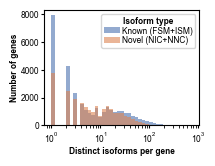

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(2.0, 1.5))

# (a) histogram of isoforms/gene, hue = known vs novel (log-spaced bins)
ax.hist(known_counts.values, bins=bins, color=KNOWN_COLOR, alpha=0.6, label="Known (FSM+ISM)")
ax.hist(novel_counts.values, bins=bins, color=NOVEL_COLOR, alpha=0.6, label="Novel (NIC+NNC)")
ax.set_xscale("log")
ax.set_xlabel("Distinct isoforms per gene")
ax.set_ylabel("Number of genes")
# axes[0].set_title(f"Distribution (robust >={ROBUST_MIN} cells)", pad=PANEL_TITLE_PAD)
ax.legend(title="Isoform type")
plt.savefig(figpath(f"04_01_isoforms_per_gene_distribution.pdf"))


# fig, ax = plt.subplots(1, 1, figsize=(2.0, 1.5))
# # (b) ECDF, one line per hue
# for cnt, col, lab in [(known_counts, KNOWN_COLOR, "Known (FSM+ISM)"),
#                       (novel_counts, NOVEL_COLOR, "Novel (NIC+NNC)")]:
#     s = np.sort(cnt.values)
#     ecdf = np.arange(1, len(s) + 1) / len(s)
#     axes[1].step(s, ecdf, where="post", color=col, label=lab)
# ax.set_xscale("log")
# ax.set_xlabel("Distinct isoforms per gene")
# ax.set_ylabel("Cumulative fraction of genes")
# # axes[1].set_title("ECDF", pad=PANEL_TITLE_PAD)
# ax.axhline(0.5, color="grey", lw=0.5, ls="--")
# ax.legend(title="Isoform type")

# plt.subplots_adjust(wspace = 0.30)
# plt.savefig(figpath(f"04_01_isoforms_per_gene_distribution.pdf"), dpi=300)
plt.show()

## 4b. Rank plots — number & fraction of novel isoforms per gene

Two ranked scatters over genes (using the robust >=10-cell isoforms from section 4):
**(a)** genes ranked by the **number** of distinct novel (NIC+NNC) isoforms they express (log–log, top genes labelled);
**(b)** genes ranked by the **fraction** of their distinct isoforms that are novel (`novel / all`, y from 0 to 1).
Reuses the per-gene `counts_robust` (all isoforms) and `novel_counts` (novel isoforms) computed above.
**(c)** distribution across genes of the **fraction of their molecules** contributed by novel isoforms (`novel molecules / all molecules`, from var `total_counts`; y = number of genes) — the expression-weighted counterpart of (b), where one rare novel model no longer counts as much as the gene's dominant isoform.
**(d)** distribution across genes of **molecule counts**, known vs novel (log-spaced bins, y = number of genes) — the molecule-level counterpart of the isoforms-per-gene histogram in section 4.

In [8]:
# Rank plots for novel isoforms per gene (robust >= ROBUST_MIN cells).
# number:   distinct novel (NIC+NNC) isoforms per gene
# fraction: novel / all distinct isoforms per gene

total_per_gene = counts_robust                                     # all distinct isoforms per gene
novel_per_gene = novel_counts.reindex(total_per_gene.index, fill_value=0)
frac_novel = (novel_per_gene / total_per_gene).rename("frac_novel")

novel_nonzero = novel_per_gene[novel_per_gene > 0].sort_values(ascending=False)
# sort by fraction descending, break ties by novel isoform count so the labelled
# top genes are the high-content 100%-novel genes rather than arbitrary singletons
frac_sorted = frac_novel.to_frame().assign(n_novel=novel_per_gene).sort_values(
    ["frac_novel", "n_novel"], ascending=False)["frac_novel"]

RED = "#d62728"   # colour for 100%-novel genes

print(f"Genes with >=1 novel isoform: {len(novel_nonzero):,} / {len(total_per_gene):,}")
print(f"Novel isoforms/gene (genes with novel): median {novel_nonzero.median():.0f} | max {novel_nonzero.max():,}")
print(f"Fraction novel/gene: mean {frac_novel.mean():.3f} | "
      f"100% novel {(frac_novel >= 1).sum():,} genes | 0% novel {(frac_novel == 0).sum():,} genes")
print("\nTop 15 genes by novel isoform count:")
print(novel_nonzero.head(15).to_string())

Genes with >=1 novel isoform: 24,150 / 37,805
Novel isoforms/gene (genes with novel): median 6 | max 625
Fraction novel/gene: mean 0.322 | 100% novel 2,634 genes | 0% novel 13,655 genes

Top 15 genes by novel isoform count:
gene_name
EEF1A1    625
SFTPC     603
MALAT1    534
UBC       378
VIM       371
PTMA      368
KRT13     342
SFTPA1    342
PRM2      339
GAPDH     306
GSN       304
SFTPB     302
TPT1      302
FTL       287
CAST      279


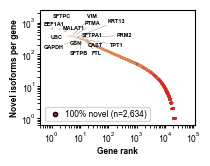

In [9]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(2.0, 1.5))

# (a) number of novel isoforms per gene, ranked (log-log), top genes labelled
# points RED where the gene is 100% novel (frac_novel == 1), else NOVEL_COLOR
c = novel_nonzero
ranks = np.arange(1, len(c) + 1)
is100_a = frac_novel.reindex(c.index).values >= 1                  # 100%-novel mask, aligned to c
colors_a = np.where(is100_a, RED, NOVEL_COLOR)
order = np.argsort(is100_a, kind="stable")   # False first, True last → red drawn last
ax.scatter(ranks[order], c.values[order], s=3, alpha=0.35,
                edgecolors="none", c=colors_a[order])
# ax.scatter(ranks, c.values, s=3, alpha=0.35, edgecolors="none", 
#                 c=colors_a)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Gene rank")
# ax.set_ylabel("Novel isoforms per gene\n(NIC+NNC, >=10 cells)")
ax.set_ylabel("Novel isoforms per gene")
ax.set_xlim(0.4, len(c) * 5)
ax.set_ylim(c[c > 0].min() * 0.6, c.max() * 4)
ax.legend(handles=[Line2D([0], [0], marker="o", color="none", markerfacecolor=RED,
                               markersize=3, label=f"100% novel (n={int(is100_a.sum()):,})")])
top = c.head(N_LABEL)
texts = [ax.text(ranks[i], v, g, fontsize=4, fontweight="bold", ha="center", va="center")
         for i, (g, v) in enumerate(top.items())]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.3),
            expand=(1.3, 1.6), min_arrow_len=1, ensure_inside_axes=True)
plt.savefig(figpath(f"04_01_ranked_novel_isoforms_per_gene.pdf"))

# # (b) fraction of a gene's isoforms that are novel, ranked (x = log rank, y = 0..1)
# f = frac_sorted
# franks = np.arange(1, len(f) + 1)
# axes[1].scatter(franks, f.values, s=3, alpha=0.35, edgecolors="none", color=NOVEL_COLOR)
# axes[1].set_xscale("log")
# axes[1].set_xlabel("Gene rank")
# axes[1].set_ylabel("Fraction novel isoforms\n(NIC+NNC / all, >=10 cells)")
# axes[1].set_ylim(-0.02, 1.02)
# axes[1].axhline(f.mean(), color="black", lw=0.5, ls="--", label=f"Mean: {f.mean():.2f}")
# axes[1].legend()
# top_f = f.head(N_LABEL)
# texts_f = [axes[1].text(franks[i], v, g, fontsize=4, fontweight="bold", ha="center", va="center")
#            for i, (g, v) in enumerate(top_f.items())]
# adjust_text(texts_f, ax=axes[1], arrowprops=dict(arrowstyle="-", color="grey", lw=0.3),
#             expand=(1.3, 1.6), min_arrow_len=1, ensure_inside_axes=True)

# # plt.subplots_adjust(wspace=0.35)
# plt.savefig(figpath(f"04_01_ranked_novel_isoforms_per_gene.pdf"), dpi=300)
# plt.show()
plt.show()

In [10]:
# Molecule-weighted novel fraction per gene: the share of a gene's MOLECULES contributed
# by novel (NIC+NNC) isoforms, rather than the share of its distinct isoform MODELS that
# are novel. The count-based fraction above weights a 1-molecule novel model exactly like
# the gene's dominant isoform, so a gene can read as "50% novel" on the strength of one
# rare structure; this version asks how much of the gene's expression actually comes from
# novel structures. Uses the var `total_counts` column (molecules per isoform), so it
# still never touches the count matrix.
assert "n_molecules" in var_df.columns, (
    "n_molecules missing -> re-run the section-1 load cell, which now also reads var "
    "'total_counts' (molecules per isoform)")

_m = var_df[var_df["n_cells"] >= ROBUST_MIN]
mol_tot = _m.groupby("gene_name", observed=True)["n_molecules"].sum()
mol_tot = mol_tot[mol_tot > 0]                    # no molecules -> no fraction to report
mol_nov = (_m[_m["structural_category"].isin(NOVEL_CATS)]
           .groupby("gene_name", observed=True)["n_molecules"].sum()
           .reindex(mol_tot.index, fill_value=0))
frac_novel_mol = (mol_nov / mol_tot).rename("frac_novel_molecules")

# sort by fraction, ties broken by novel-molecule count so the labelled genes at the
# 100% end are well-supported rather than single-molecule singletons
frac_mol_sorted = (frac_novel_mol.to_frame()
                   .assign(n_mol=mol_tot, n_novel_mol=mol_nov)
                   .sort_values(["frac_novel_molecules", "n_novel_mol"], ascending=False))

pooled_frac_mol = float(mol_nov.sum() / mol_tot.sum())
print(f"Genes with a molecule-weighted novel fraction: {len(frac_novel_mol):,}")
print(f"  mean {frac_novel_mol.mean():.3f} | median {frac_novel_mol.median():.3f} | "
      f"100% novel {(frac_novel_mol >= 1).sum():,} | 0% novel {(frac_novel_mol == 0).sum():,}")
print(f"  pooled across all genes: {pooled_frac_mol:.3f} "
      f"({int(mol_nov.sum()):,} novel / {int(mol_tot.sum()):,} molecules)")

# the two definitions are NOT interchangeable - quantify the gap rather than assume it
_cmp = pd.concat([frac_novel.rename("by_isoform_count"),
                  frac_novel_mol.rename("by_molecules")], axis=1).dropna()
if len(_cmp) > 1:
    print(f"  vs the isoform-count fraction (n={len(_cmp):,} shared genes): Spearman "
          f"{_cmp.corr(method='spearman').iloc[0, 1]:.3f} | "
          f"mean(molecules - count) {(_cmp['by_molecules'] - _cmp['by_isoform_count']).mean():+.3f}")

print("\nTop 15 genes by molecule-weighted novel fraction:")
print(frac_mol_sorted.head(15).round(3).to_string())

Genes with a molecule-weighted novel fraction: 37,805
  mean 0.195 | median 0.040 | 100% novel 2,634 | 0% novel 13,655
  pooled across all genes: 0.054 (34,414,632 novel / 638,488,320 molecules)
  vs the isoform-count fraction (n=37,805 shared genes): Spearman 0.906 | mean(molecules - count) -0.127

Top 15 genes by molecule-weighted novel fraction:
                 frac_novel_molecules    n_mol  n_novel_mol
gene_name                                                  
ENSG00000285625                   1.0  70342.0      70342.0
SNHG25                            1.0  62774.0      62774.0
ENSG00000277702                   1.0  11654.0      11654.0
ENSG00000285526                   1.0   8244.0       8244.0
ENSG00000240040                   1.0   7573.0       7573.0
ENSG00000227307                   1.0   3697.0       3697.0
MMEL1-AS1                         1.0   3021.0       3021.0
ENSG00000225144                   1.0   2810.0       2810.0
ZBED6                             1.0   2713.0   

Genes: 37,805 | 0% novel 13,655 (36.1%) | >=1 novel 24,150 (63.9%) | 100% novel 2,634 (7.0%)
Gene-mean fraction 0.195 | median 0.040 | pooled (molecule-weighted) 0.054
NOTE end bins are 0.025 wide: first bar 17,173 (= 13,655 exactly 0 + 3,518 in (0,0.025)) | last bar 2,715 (= 2,634 exactly 1 + 81 below)


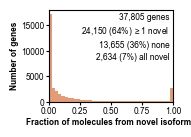

In [11]:
from matplotlib.lines import Line2D

# (c) Distribution across genes of the molecule-weighted novel fraction:
# x = share of a gene's molecules contributed by novel (NIC+NNC) isoforms, y = number of genes.
# Every gene with >=1 molecule is included, so the bar at 0 is the genes with no novel
# molecules at all and the bar at 1 the entirely-novel genes.
fbins = np.linspace(0, 1, 41)

# exact set-membership counts -- these are the quoted numbers, computed from the values
# rather than read off bar heights (the end bins are 0.025 wide, so they also catch
# near-zero / near-one genes; the printout below reports that gap explicitly)
_n_tot = len(frac_novel_mol)
_n_none = int((frac_novel_mol == 0).sum())
_n_any = int((frac_novel_mol > 0).sum())
_n_all = int((frac_novel_mol >= 1).sum())

fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.2))
_counts, _edges, _ = ax.hist(frac_novel_mol.values, bins=fbins, color=NOVEL_COLOR, alpha=0.8)
ax.set_xlabel("Fraction of molecules from novel isoforms")
ax.set_ylabel("Number of genes")
ax.set_xlim(0, 1)
# ax.set_yscale("log")   # uncomment if the 0%-novel spike flattens the rest of the range
# ax.axvline(frac_novel_mol.mean(), color="black", lw=0.5, ls="--")
# ax.axvline(pooled_frac_mol, color="grey", lw=0.5, ls=":")

# the quoted numbers, on the plot. Placed as a text block rather than as bar labels: the
# end bins are wider than the exact 0 / 1 classes, so a bar label would overstate them.
ax.text(0.97, 0.97,
        f"{_n_tot:,} genes\n"
        f"{_n_any:,} ({_n_any/_n_tot*100:.0f}%) $\\geq$1 novel\n"
        f"{_n_none:,} ({_n_none/_n_tot*100:.0f}%) none\n"
        f"{_n_all:,} ({_n_all/_n_tot*100:.0f}%) all novel",
        transform=ax.transAxes, ha="right", va="top", fontsize=6, linespacing=1.4)

# ax.legend(handles=[
#     Line2D([0], [0], color="black", lw=0.5, ls="--",
#            label=f"Gene mean: {frac_novel_mol.mean():.2f}"),
#     Line2D([0], [0], color="grey", lw=0.5, ls=":",
#            label=f"Pooled: {pooled_frac_mol:.2f}"),
# ], fontsize=4, loc="upper center")

print(f"Genes: {_n_tot:,} | 0% novel {_n_none:,} ({_n_none/_n_tot*100:.1f}%) "
      f"| >=1 novel {_n_any:,} ({_n_any/_n_tot*100:.1f}%) "
      f"| 100% novel {_n_all:,} ({_n_all/_n_tot*100:.1f}%)")
print(f"Gene-mean fraction {frac_novel_mol.mean():.3f} | median {frac_novel_mol.median():.3f} | "
      f"pooled (molecule-weighted) {pooled_frac_mol:.3f}")
# the end bars are NOT the exact classes - say by how much, so the annotation is not
# mistaken for a bar height
print(f"NOTE end bins are {fbins[1]-fbins[0]:.3f} wide: first bar {int(_counts[0]):,} "
      f"(= {_n_none:,} exactly 0 + {int(_counts[0])-_n_none:,} in (0,{fbins[1]:.3f})) | "
      f"last bar {int(_counts[-1]):,} (= {_n_all:,} exactly 1 + {int(_counts[-1])-_n_all:,} below)")

plt.savefig(figpath("04_01_novel_molecule_fraction_per_gene_distribution.pdf"))
plt.show()

Genes plotted of 37,805: known 32,127 | novel 24,150 (excluded for contributing 0 molecules of that class: known 5,678, novel 13,655)
Molecules per gene — known: median 875, max 39,599,720 | novel: median 248, max 941,424


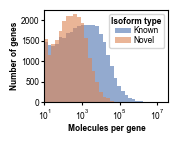

In [12]:
# (d) Distribution across genes of MOLECULE counts, known vs novel — the molecule-level
# counterpart of the isoforms-per-gene histogram in section 4. Same conventions: log-spaced
# bins, y = number of genes. `mol_nov` comes from the cell above; known molecules are summed
# explicitly from KNOWN_CATS rather than as (total - novel), because the total also contains
# fusion/genic/intergenic isoforms that are neither known nor novel.
_m = var_df[var_df["n_cells"] >= ROBUST_MIN]
mol_known = (_m[_m["structural_category"].isin(KNOWN_CATS)]
             .groupby("gene_name", observed=True)["n_molecules"].sum())

# a log x-axis cannot show zeros, so genes contributing none of that class are excluded
_kn, _nv = mol_known[mol_known > 0], mol_nov[mol_nov > 0]
_n_genes = len(mol_tot)          # all genes with >=1 molecule
print(f"Genes plotted of {_n_genes:,}: known {len(_kn):,} | novel {len(_nv):,} "
      f"(excluded for contributing 0 molecules of that class: "
      f"known {_n_genes - len(_kn):,}, novel {_n_genes - len(_nv):,})")
print(f"Molecules per gene — known: median {_kn.median():,.0f}, max {_kn.max():,.0f} | "
      f"novel: median {_nv.median():,.0f}, max {_nv.max():,.0f}")

_allmax = max(float(_kn.max()), float(_nv.max()))
mbins = np.logspace(0, np.log10(_allmax), 40)

fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.2))
ax.hist(_kn.values, bins=mbins, color=KNOWN_COLOR, alpha=0.6, label="Known")
ax.hist(_nv.values, bins=mbins, color=NOVEL_COLOR, alpha=0.6, label="Novel")
ax.set_xscale("log")
plt.xlim((10,max(_kn.values.max(), _nv.values.max())))
ax.set_xlabel("Molecules per gene")
ax.set_ylabel("Number of genes")
ax.legend(title="Isoform type")
plt.savefig(figpath("04_01_novel_molecules_per_gene_distribution.pdf"))
plt.show()

## 4c. Novel-fraction distribution by gene biotype

Same per-gene novel fraction (`novel / all` distinct isoforms, robust >=10 cells) as section 4b,
but split by **gene biotype**. Biotypes come from `csvs/transcripts_to_genes_with_biotypes.txt`
(GENCODE `gene_biotype`, mapped `gene_name -> gene_biotype`), collapsed into broad classes
(protein_coding, lncRNA, pseudogene, IG/TR gene, small ncRNA, TEC, other).

In [13]:
# --- Map gene_name -> gene_biotype and collapse into broad classes ---
biotypes = pd.read_csv(f"{CSVS_DIR}/transcripts_to_genes_with_biotypes.txt", sep="\t")
# one biotype per gene symbol (dedup; take the first, they are consistent per gene)
gene2biotype = (biotypes.dropna(subset=["gene_name", "gene_biotype"])
                        .drop_duplicates("gene_name")
                        .set_index("gene_name")["gene_biotype"])

def broad_biotype(bt):
    if not isinstance(bt, str):
        return "other"
    if bt == "protein_coding":
        return "protein_coding"
    if bt == "lncRNA":
        return "lncRNA"
    if "pseudogene" in bt:
        return "pseudogene"
    if (bt.startswith("IG_") or bt.startswith("TR_")) and bt.endswith("_gene"):
        return "IG/TR gene"
    if bt in {"miRNA", "snRNA", "snoRNA", "scaRNA", "misc_RNA", "rRNA",
              "Mt_tRNA", "Mt_rRNA", "sRNA", "scRNA", "ribozyme", "vault_RNA"}:
        return "small ncRNA"
    if bt == "TEC":
        return "TEC"
    return "other"

# frac_novel (from section 4b) is per-gene, indexed by gene_name
bt_df = frac_novel.to_frame().copy()
bt_df["gene_biotype"] = bt_df.index.map(gene2biotype)
bt_df["biotype_class"] = bt_df["gene_biotype"].map(broad_biotype)
n_unmapped = bt_df["gene_biotype"].isna().sum()
print(f"Genes: {len(bt_df):,} | without a biotype match: {n_unmapped:,}")

# order classes by median novel fraction (descending), keep only classes with >= MIN_GENES genes
MIN_GENES = 20
grp = bt_df.groupby("biotype_class", observed=True)["frac_novel"]
sizes = grp.size()
keep = sizes[sizes >= MIN_GENES].index
order = (grp.median().loc[keep].sort_values(ascending=False)).index.tolist()

print("\nNovel fraction by biotype class (robust >=%d cells):" % ROBUST_MIN)
summary = pd.DataFrame({
    "n_genes": sizes,
    "mean_frac_novel": grp.mean(),
    "median_frac_novel": grp.median(),
    "frac_100pct_novel": grp.apply(lambda s: (s >= 1).mean()),
}).loc[order].round(3)
print(summary.to_string())

Genes: 37,805 | without a biotype match: 2,405

Novel fraction by biotype class (robust >=1 cells):
                n_genes  mean_frac_novel  median_frac_novel  frac_100pct_novel
biotype_class                                                                 
lncRNA            11466            0.434              0.500              0.173
protein_coding    18201            0.351              0.333              0.016
IG/TR gene          194            0.192              0.000              0.021
TEC                 714            0.003              0.000              0.001
other              2424            0.040              0.000              0.026
pseudogene         4352            0.155              0.000              0.065
small ncRNA         454            0.001              0.000              0.000


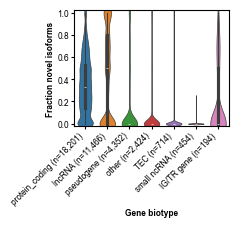

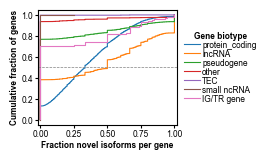

In [14]:
# --- Distribution of per-gene novel fraction, split by gene biotype class ---

# Order categories by number of genes (n), descending
order = sorted(order, key=lambda c: sizes[c], reverse=True)

palette = dict(zip(order, sns.color_palette("tab10", len(order))))
fig, ax = plt.subplots(1, 1, figsize=(2.0, 1.5))

# (a) box + strip of novel fraction per biotype class (ordered by n genes)
plot_df = bt_df[bt_df["biotype_class"].isin(order)].copy()
sns.violinplot(data=plot_df, x="biotype_class", y="frac_novel", order=order, ax=ax,
               palette=palette, linewidth=0.5, width=0.7,
               # fliersize=0,
               )
ax.set_xlabel("Gene biotype")
ax.set_ylabel("Fraction novel isoforms\n(NIC+NNC / all, >=1 cell)")
ax.set_ylabel("Fraction novel isoforms")
ax.set_ylim(-0.02, 1.02)
ax.set_xticklabels([f"{c} (n={sizes[c]:,})" for c in order], rotation=45, ha="right")
plt.savefig(figpath(f"04_01_novel_fraction_by_biotype_violin.pdf"))
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(1.8, 1.5))
# (b) ECDF of novel fraction, one line per biotype class (same order)
for c in order:
    s = np.sort(bt_df.loc[bt_df["biotype_class"] == c, "frac_novel"].values)
    ecdf = np.arange(1, len(s) + 1) / len(s)
    ax.step(s, ecdf, where="post", color=palette[c], lw=0.8, label=c)
ax.set_xlabel("Fraction novel isoforms per gene")
ax.set_ylabel("Cumulative fraction of genes")
ax.set_xlim(-0.02, 1.02)
ax.axhline(0.5, color="grey", lw=0.5, ls="--")
ax.legend(title="Gene biotype", loc=6, bbox_to_anchor=(1.0, 0.5), 
          labelspacing  = 0, frameon=False)

plt.subplots_adjust(wspace=0.3)
plt.savefig(figpath(f"04_01_novel_fraction_by_biotype.pdf"))


## 4d. Distribution (histogram) — novel isoforms per gene, **protein-coding genes only**

Same two ranked scatters as section 4b, but restricted to genes whose `gene_biotype` is
`protein_coding` (map from `csvs/transcripts_to_genes_with_biotypes.txt`, built in 4c):
**(a)** genes ranked by the **number** of distinct novel (NIC+NNC) isoforms; **(b)** ranked by the
**fraction** of their distinct isoforms that are novel. Reuses `counts_robust` / `novel_counts`.

In [15]:
# Rank plot as in 4b, restricted to protein_coding genes (gene2biotype from 4c).
# Points are coloured RED where the gene is 100% novel (frac_novel == 1), else NOVEL_COLOR.

pc_genes = gene2biotype.index[gene2biotype == "protein_coding"]

total_pc = counts_robust[counts_robust.index.isin(pc_genes)]          # all distinct isoforms per PC gene
novel_pc = novel_counts.reindex(total_pc.index, fill_value=0)         # novel isoforms per PC gene
frac_novel_pc = (novel_pc / total_pc).rename("frac_novel")

novel_pc_nonzero = novel_pc[novel_pc > 0].sort_values(ascending=False)

RED = "#d62728"   # colour for 100%-novel genes
print(f"Protein-coding genes (robust >=%d cells): {len(total_pc):,} | "
      f"with >=1 novel isoform: {len(novel_pc_nonzero):,} | "
      f"100%% novel: {int((frac_novel_pc >= 1).sum()):,}" % ROBUST_MIN)

print(f"Novel isoforms/gene (PC genes with novel): median {novel_pc_nonzero.median():.0f} | max {novel_pc_nonzero.max():,}")
print(f"Fraction novel/PC gene: mean {frac_novel_pc.mean():.3f} | "
      f"100% novel {(frac_novel_pc >= 1).sum():,} genes | 0% novel {(frac_novel_pc == 0).sum():,} genes")
print("\nTop 15 protein-coding genes by novel isoform count:")
print(novel_pc_nonzero.head(15).to_string())

Protein-coding genes (robust >=1 cells): 18,201 | with >=1 novel isoform: 15,817 | 100% novel: 297
Novel isoforms/gene (PC genes with novel): median 10 | max 625
Fraction novel/PC gene: mean 0.351 | 100% novel 297 genes | 0% novel 2,384 genes

Top 15 protein-coding genes by novel isoform count:
gene_name
EEF1A1    625
SFTPC     603
UBC       378
VIM       371
PTMA      368
KRT13     342
SFTPA1    342
PRM2      339
GAPDH     306
GSN       304
SFTPB     302
TPT1      302
FTL       287
CAST      279
EEF1D     278


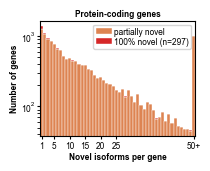

In [16]:
# Histogram: distribution of novel isoforms per protein-coding gene (genes with >=1 novel),
# stacked by whether the gene is 100% novel (all isoforms novel) vs partially novel.
c = novel_pc_nonzero
is100 = frac_novel_pc.reindex(c.index).values >= 1          # 100%-novel genes, aligned to c
CAP = 50                                                    # top bin catches CAP+ novel isoforms/gene
bins = np.arange(0.5, CAP + 1.5, 1)
v_part = c[~is100].clip(upper=CAP).values
v_100  = c[is100].clip(upper=CAP).values

fig, ax = plt.subplots(figsize=(2.0, 1.5))
ax.hist([v_part, v_100], bins=bins, stacked=True, color=[NOVEL_COLOR, RED],
        edgecolor="white", linewidth=0.3,
        label=["partially novel", f"100% novel (n={int(is100.sum()):,})"])
ax.set_yscale("log")
ax.set_xlabel("Novel isoforms per gene")
ax.set_ylabel("Number of genes")
ax.set_title("Protein-coding genes", pad=PANEL_TITLE_PAD)
ax.set_xlim(bins[0], bins[-1])
_ticks = [1, 5, 10, 15, 20, 25, CAP]
ax.set_xticks(_ticks)
ax.set_xticklabels([str(t) for t in _ticks[:-1]] + [f"{CAP}+"])
ax.legend()

plt.savefig(figpath(f"04_01_novel_isoforms_per_gene_protein_coding_hist.pdf"))
plt.show()

## 4e. Pooled isoform-level novel fraction

Fraction of **robustly expressed isoforms** (>= ROBUST_MIN cells) that are novel (NIC+NNC), for all genes and for protein-coding genes only.


In [17]:
# Pooled ISOFORM-level novel fraction among robustly expressed isoforms (>= ROBUST_MIN cells).
# "Novel" = NIC + NNC. Reported for all robust isoforms and the protein-coding subset.
KNOWN_CATS = {"full-splice_match", "incomplete-splice_match"}
NOVEL_CATS = {"novel_in_catalog", "novel_not_in_catalog"}
KNOWN_COLOR, NOVEL_COLOR, OTHER_COLOR = "#4c72b0", "#dd8452", "#bfbfbf"

# gene_name -> gene_biotype (same source as section 4c)
_bt = pd.read_csv(f"{CSVS_DIR}/transcripts_to_genes_with_biotypes.txt", sep="\t")
_g2b = (_bt.dropna(subset=["gene_name", "gene_biotype"]).drop_duplicates("gene_name")
           .set_index("gene_name")["gene_biotype"])

robust = var_df[var_df["n_cells"] >= ROBUST_MIN]
pc = robust[robust["gene_name"].map(_g2b).eq("protein_coding")]

def frac_breakdown(df):
    n = len(df)
    k = int(df["structural_category"].isin(KNOWN_CATS).sum())
    nov = int(df["structural_category"].isin(NOVEL_CATS).sum())
    other = n - k - nov
    return np.array([k, nov, other]) / n, n, nov

(f_all, n_all, nov_all) = frac_breakdown(robust)
(f_pc, n_pc, nov_pc) = frac_breakdown(pc)
print(f"Robust isoforms: all {n_all:,} | protein-coding {n_pc:,}")
print(f"Novel (NIC+NNC) fraction of ALL robust isoforms: {nov_all:,}/{n_all:,} = {f_all[1]:.1%}")
print(f"Novel (NIC+NNC) fraction within PROTEIN-CODING genes: {nov_pc:,}/{n_pc:,} = {f_pc[1]:.1%}")

# --- Figure data: stacked Known / Novel / Other for All vs Protein-coding ---
groups = ["All robust", "Protein-coding"]
mat = np.vstack([f_all, f_pc])   # rows = groups, cols = [known, novel, other]
labels = ["Known (FSM+ISM)", "Novel (NIC+NNC)", "Other categories"]
colors = [KNOWN_COLOR, NOVEL_COLOR, OTHER_COLOR]

Robust isoforms: all 854,410 | protein-coding 752,219
Novel (NIC+NNC) fraction of ALL robust isoforms: 321,443/854,410 = 37.6%
Novel (NIC+NNC) fraction within PROTEIN-CODING genes: 273,466/752,219 = 36.4%


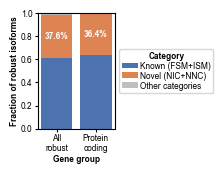

In [18]:
fig, ax = plt.subplots(figsize=(1.0, 1.5))
bottom = np.zeros(len(groups))
for j, (lab, col) in enumerate(zip(labels, colors)):
    ax.bar(groups, mat[:, j], bottom=bottom, color=col, label=lab)
    bottom += mat[:, j]
# annotate the novel segment with its percentage
novel_bottom = mat[:, 0]
for i in range(len(groups)):
    ax.text(i, novel_bottom[i] + mat[i, 1] / 2, f"{mat[i, 1]:.1%}",
            ha="center", va="center", fontsize=6, color="white", fontweight="bold")
ax.set_ylim(0, 1)
ax.set_xticklabels(["All\nrobust", "Protein\ncoding"])
ax.set_xlabel("Gene group")
ax.set_ylabel("Fraction of robust isoforms")
ax.legend(loc=6, bbox_to_anchor=(1.0, 0.5), ncol=1, title = "Category")
plt.savefig(figpath(f"04_01_pooled_novel_isoform_fraction.pdf"))
plt.show()

## 5. Save ranked table

In [19]:
out = pd.DataFrame({
    f"n_isoforms_detected_ge{DETECT_MIN}": counts_detect,
    f"n_isoforms_robust_ge{ROBUST_MIN}": counts_robust,
}).fillna(0).astype(int)
out = out.sort_values(f"n_isoforms_robust_ge{ROBUST_MIN}", ascending=False)
out.index.name = "gene_name"
out["rank_robust"] = np.arange(1, len(out) + 1)

out_path = f"{CSVS_DIR}/isoforms_per_gene_ranked.csv"
out.to_csv(out_path)
print("Wrote", out_path, "|", out.shape)
out.head(15)

Wrote ./../csvs/isoforms_per_gene_ranked.csv | (37805, 3)


,n_isoforms_detected_ge1,n_isoforms_robust_ge1,rank_robust
gene_name,,,
CAST,874,874,1
DST,825,825,2
TTN,799,799,3
KTN1,790,790,4
SYNE2,785,785,5
EEF1A1,695,695,6
MACF1,684,684,7
SYNE1,671,671,8
SFTPC,653,653,9
